In [1]:
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import sys
import numpy as np
import xarray as xr
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from pathlib import Path
project_root = Path.cwd().parent  
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.snotel_utils import SNOTEL

from matplotlib.gridspec import GridSpec

import cartopy.crs as ccrs
from matplotlib.patches import Rectangle

In [2]:
path_to_geog = '/bsuscratch/stanleyakor/uppercolorado/static_inputs/wrfout_d02_2000-04-08_00:00:00'
path_to_header = '/bsuscratch/stanleyakor/uppercolorado/ml_frameworks/evaluation/DOWNLOAD_SNOTEL/NRCS_SNOTEL_Locations_noAlaska.csv'
path_to_csv = '/bsuscratch/stanleyakor/uppercolorado/ml_frameworks/evaluation/DOWNLOAD_SNOTEL/snotel_data/'

In [3]:
snotel_routine =  SNOTEL(var = 'SNOW',\
                 path_to_header = path_to_header,\
                 path_to_csv = path_to_csv ,\
                 path_to_geog =None,\
                 path_to_wrf_file = None,\
                 start =  None,\
                 end =  None)

In [4]:
lat,lon,_,_,elevation = snotel_routine.collect_snotel_info()

In [5]:
def plot_wus_domain_ax(ax):
    west_minlon, west_minlat = -125.0, 31.0
    west_maxlon, west_maxlat = -102.0, 49.5

    roi_minlat = 36.810326
    roi_minlon = -109.0985
    roi_maxlat = 40.317627
    roi_maxlon = -105.09583

    proj = ccrs.PlateCarree()

    ax.set_extent([west_minlon, west_maxlon, west_minlat, west_maxlat], crs=proj)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=1)

    states = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lines",
        scale="50m",
        facecolor="none",
    )
    ax.add_feature(states, edgecolor="black", linewidth=0.6, zorder=2)

    gl = ax.gridlines(
        crs=proj, draw_labels=True,
        linewidth=0.4, color="gray", alpha=0.6, linestyle="--"
    )
    gl.xlocator = plt.FixedLocator(list(range(-125, -100 + 1, 5)))
    gl.ylocator = plt.FixedLocator(list(range(30, 50 + 1, 5)))
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    west_rect = Rectangle(
        (west_minlon, west_minlat),
        west_maxlon - west_minlon,
        west_maxlat - west_minlat,
        facecolor="none", edgecolor="tab:blue",
        linewidth=2.0, transform=proj, zorder=3,
    )
    ax.add_patch(west_rect)

    roi_rect = Rectangle(
        (roi_minlon, roi_minlat),
        roi_maxlon - roi_minlon,
        roi_maxlat - roi_minlat,
        facecolor="none", edgecolor="red",
        linewidth=1.0, transform=proj, zorder=4,
    )
    ax.add_patch(roi_rect)

    roi_fill = Rectangle(
        (roi_minlon, roi_minlat),
        roi_maxlon - roi_minlon,
        roi_maxlat - roi_minlat,
        facecolor="red", alpha=0.15,
        edgecolor="none", transform=proj, zorder=3.5,
    )
    ax.add_patch(roi_fill)


In [6]:
import xarray as xr

def plot_colorado_rockies_ax(fig, ax, lat, lon, path_to_geog):
    # scatter sites
    for la, lo in zip(lat, lon):
        ax.scatter(lo, la, marker='o', s=30,
                   color='magenta', edgecolor='black',
                   linewidth=0.8, zorder=5)

    # background topography
    geog = xr.open_dataset(path_to_geog)
    hgt = geog['HGT'].isel(Time=0) if "Time" in geog["HGT"].dims else geog["HGT"]

    im = ax.imshow(
        hgt,
        extent=(geog.XLONG.min(), geog.XLONG.max(),
                geog.XLAT.min(), geog.XLAT.max()),
        cmap='terrain', origin='lower', alpha=1.0
    )

    diff = 0.45
    ax.set_xticks(np.linspace(geog.XLONG.min().values + diff, geog.XLONG.max().values - diff, 4))
    ax.set_yticks(np.linspace(geog.XLAT.min().values + diff, geog.XLAT.max().values - diff, 4))

    lon_ticks = ax.get_xticks()
    lat_ticks = ax.get_yticks()

    lon_labels = [f'{abs(v):.1f}°{"W" if v < 0 else "E"}' for v in lon_ticks]
    lat_labels = [f'{abs(v):.1f}°{"S" if v < 0 else "N"}' for v in lat_ticks]

    ax.set_xticklabels(lon_labels)
    ax.set_yticklabels(lat_labels)
    ax.tick_params(axis='both', labelsize=6)
    cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.02)
    cbar.ax.tick_params(labelsize=6)
    cbar.set_label('Elevation (m)', fontsize=6)


In [7]:
def plot_ecdf_ax(ax, elev_m, xlabel="Elevation (m)", title="ECDF"):
    elev = np.asarray(elev_m, dtype=float)
    elev = elev[~np.isnan(elev)]
    n = elev.size

    x = np.sort(elev)
    y = np.arange(1, n + 1) / n

    ax.plot(x, y, linewidth=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fraction of sites")
    # ax.set_title(title)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)

    for q in [0.25, 0.5, 0.75]:
        val = np.quantile(elev, q)
        ax.axvline(val, linestyle="--", alpha=0.6)
        ax.text(val, q, f"{int(q*100)}%", ha="right", va="bottom",fontsize=7)
    ax.tick_params(axis='both', labelsize=6)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Fraction of sites", fontsize=8)

    # Move ylabel inside the axes
    ax.yaxis.set_label_coords(0.07, 0.5)
    ax.xaxis.set_label_coords(0.45, 0.1)

In [8]:
def make_abc_figure(lat, lon, elevations_m, path_to_geog):
    fig = plt.figure(figsize=(9, 4.5), dpi=200)

    gs = GridSpec(
        nrows=2, ncols=2,
        width_ratios=[3.2, 1.6],
        height_ratios=[0.9, 0.7],   # B taller than C
        wspace=0.15, hspace=0.18
    )

    
    proj = ccrs.PlateCarree()
    axA = fig.add_subplot(gs[:, 0], projection=proj)

   
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 1])

    
    plot_wus_domain_ax(axA)  
    plot_colorado_rockies_ax(fig, axB, lat, lon, path_to_geog)  
    plot_ecdf_ax(axC, elevations_m, title="")  

    
    for label, ax in zip(["A", "B", "C"], [axA, axB, axC]):
        ax.text(
            0.01, 0.99, label,
            transform=ax.transAxes,
            fontsize=8,
            fontweight="bold",
            va="top", ha="left",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
        )
    plt.savefig('../figures/study_domain.pdf')
    plt.show()


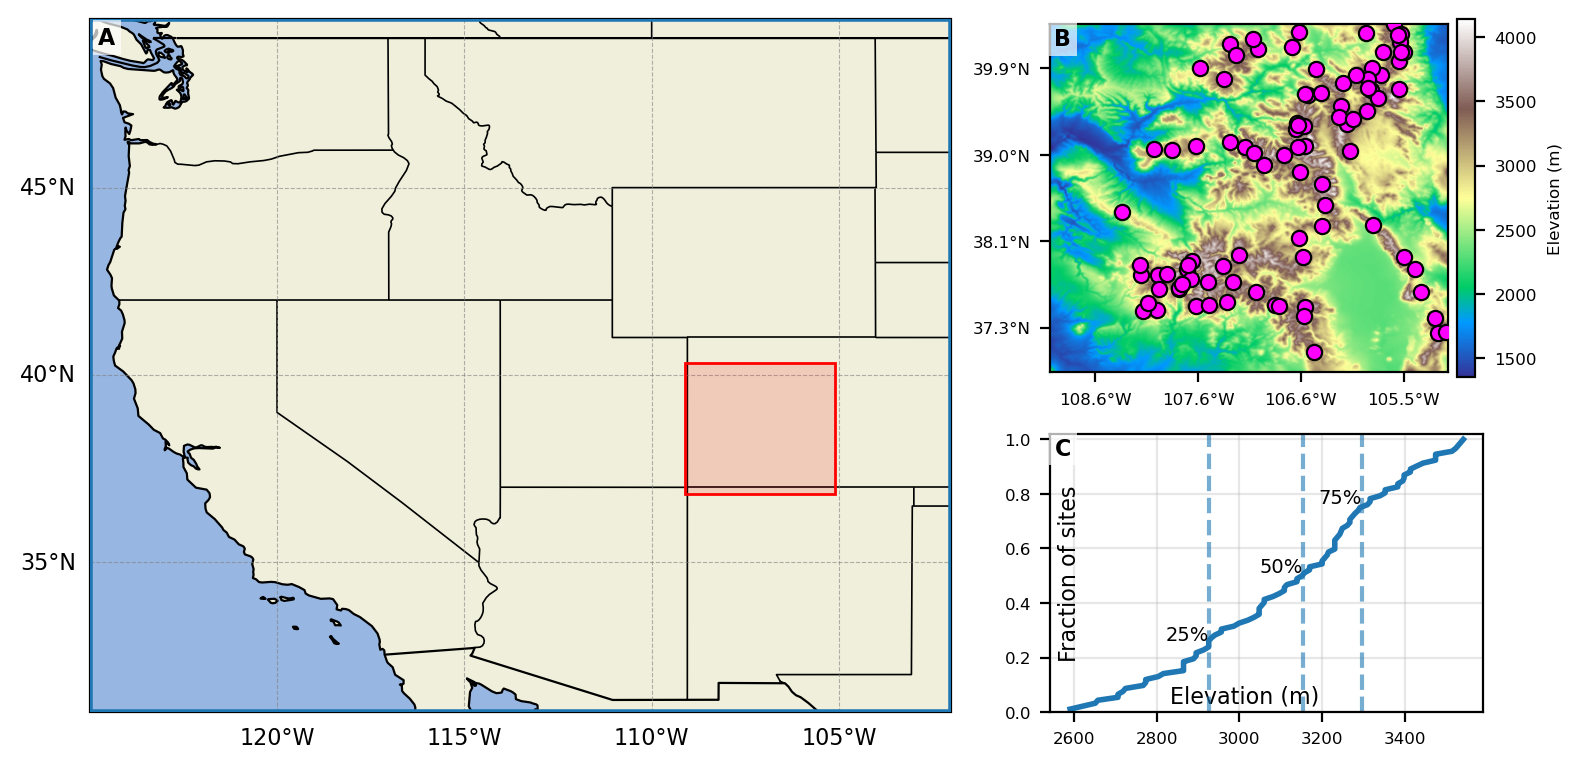

In [9]:
elevations_m = (1/3.281) * np.array(elevation)  #  feet -> meters conversion

make_abc_figure(
    lat=np.array(lat),
    lon=np.array(lon),
    elevations_m=elevations_m,
    path_to_geog=path_to_geog
)
